# BUSI Dataset - Breast Ultrasound Classification (Final Improved Version)
## Classifying: Normal | Benign | Malignant

### Improvements in this version:
- ROI Cropping using segmentation masks (biggest improvement)
- Random Oversampling for class balance
- Label Smoothing in loss function
- Gradient Clipping for stable training
- AdamW optimizer with weight decay
- Boosted malignant class weight
- More epochs with higher patience

In [ ]:


import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
print('Done installing libraries.')

Done installing libraries.


In [ ]:

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, cohen_kappa_score,
    matthews_corrcoef, log_loss, balanced_accuracy_score,
    average_precision_score, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE, RandomOverSampler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('All libraries imported.')

Device: cuda
All libraries imported.


In [ ]:

CONFIG = {
    'img_size'    : 224,
    'batch_size'  : 32,
    'num_epochs'  : 50,     # IMPROVED: was 25
    'lr'          : 1e-4,
    'num_classes' : 3,
    'class_names' : ['benign', 'malignant', 'normal'],
    'patience'    : 10,     # IMPROVED: was 7
}

CLASS_MAP    = {name: idx for idx, name in enumerate(CONFIG['class_names'])}
IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}

DATA_ROOT = '/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'

print('Configuration:')
for k, v in CONFIG.items():
    print(f'  {k:15} = {v}')
print(f'\nPath exists: {os.path.exists(DATA_ROOT)}')

Configuration:
  img_size        = 224
  batch_size      = 32
  num_epochs      = 50
  lr              = 0.0001
  num_classes     = 3
  class_names     = ['benign', 'malignant', 'normal']
  patience        = 10

Path exists: True


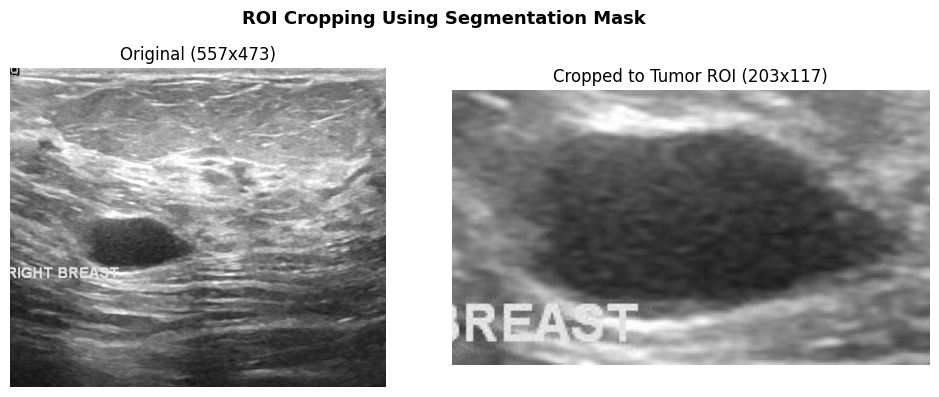

ROI cropping removes background -> model focuses on tumor only
This is the main reason papers achieve 90%+ accuracy on BUSI


In [ ]:

def crop_with_mask(image_path, padding=20):
    """
    Crop image to tumor region using its segmentation mask.
    If no mask found, returns the full original image.
    padding = extra pixels to keep around the tumor border.
    """
    
    base      = os.path.splitext(image_path)[0]
    mask_path = base + '_mask.png'

   
    if not os.path.exists(mask_path):
        return Image.open(image_path).convert('RGB')

    img  = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        return Image.open(image_path).convert('RGB')

    
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    
    coords = cv2.findNonZero(binary_mask)
    if coords is None:
        return Image.open(image_path).convert('RGB')

    x, y, w, h = cv2.boundingRect(coords)

  
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(img.shape[1], x + w + padding)
    y2 = min(img.shape[0], y + h + padding)

  
    cropped     = img[y1:y2, x1:x2]
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    return Image.fromarray(cropped_rgb)


sample_dir  = os.path.join(DATA_ROOT, 'benign')
sample_file = [f for f in os.listdir(sample_dir)
               if '_mask' not in f and f.endswith('.png')][0]
sample_path = os.path.join(sample_dir, sample_file)

original = Image.open(sample_path).convert('RGB')
cropped  = crop_with_mask(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('ROI Cropping Using Segmentation Mask', fontsize=13, fontweight='bold')
axes[0].imshow(original)
axes[0].set_title(f'Original ({original.size[0]}x{original.size[1]})')
axes[0].axis('off')
axes[1].imshow(cropped)
axes[1].set_title(f'Cropped to Tumor ROI ({cropped.size[0]}x{cropped.size[1]})')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('roi_cropping_example.png', dpi=120, bbox_inches='tight')
plt.show()
print('ROI cropping removes background -> model focuses on tumor only')
print('This is the main reason papers achieve 90%+ accuracy on BUSI')

In [ ]:

def load_dataset(data_root, class_names):
    records = []
    for class_name in class_names:
        class_folder = os.path.join(data_root, class_name)
        if not os.path.exists(class_folder):
            print(f'WARNING: Not found -> {class_folder}')
            continue
        for filename in sorted(os.listdir(class_folder)):
            if '_mask' in filename.lower():
                continue
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                records.append({
                    'filepath'   : os.path.join(class_folder, filename),
                    'label_name' : class_name,
                    'label'      : CLASS_MAP[class_name]
                })
    return pd.DataFrame(records)


df = load_dataset(DATA_ROOT, CONFIG['class_names'])
print(f'Total images: {len(df)}')
print('\nImages per class:')
for cls, cnt in df['label_name'].value_counts().items():
    bar = '#' * (cnt // 5)
    print(f'  {cls:12}: {cnt:4d}  {bar}')

Total images: 780

Images per class:
  benign      :  437  #######################################################################################
  malignant   :  210  ##########################################
  normal      :  133  ##########################


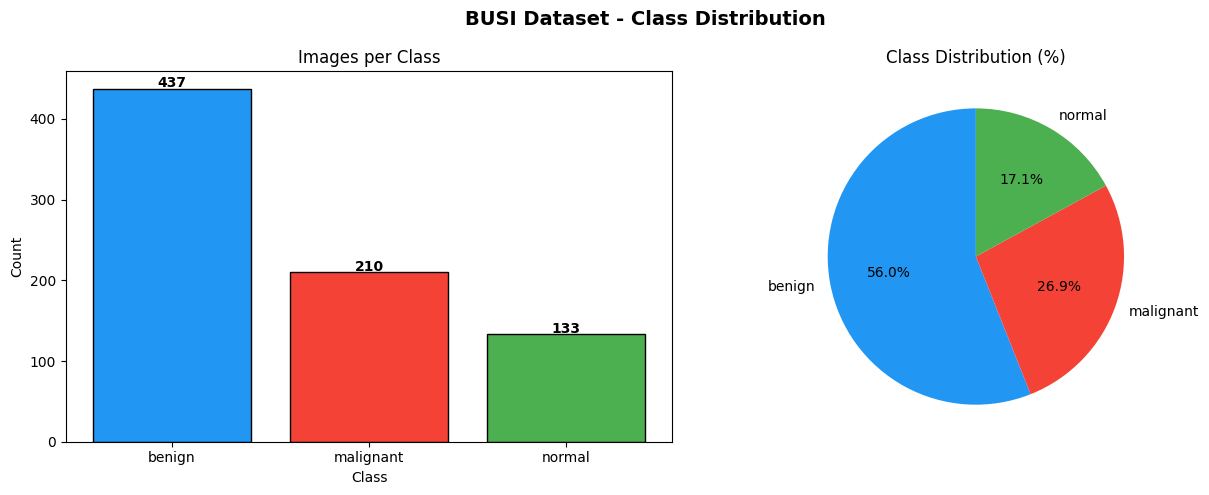

Class imbalance confirmed. Benign dominates.


In [ ]:


counts = df['label_name'].value_counts()
colors = ['#2196F3', '#F44336', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BUSI Dataset - Class Distribution', fontsize=14, fontweight='bold')

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Images per Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Class imbalance confirmed. Benign dominates.')

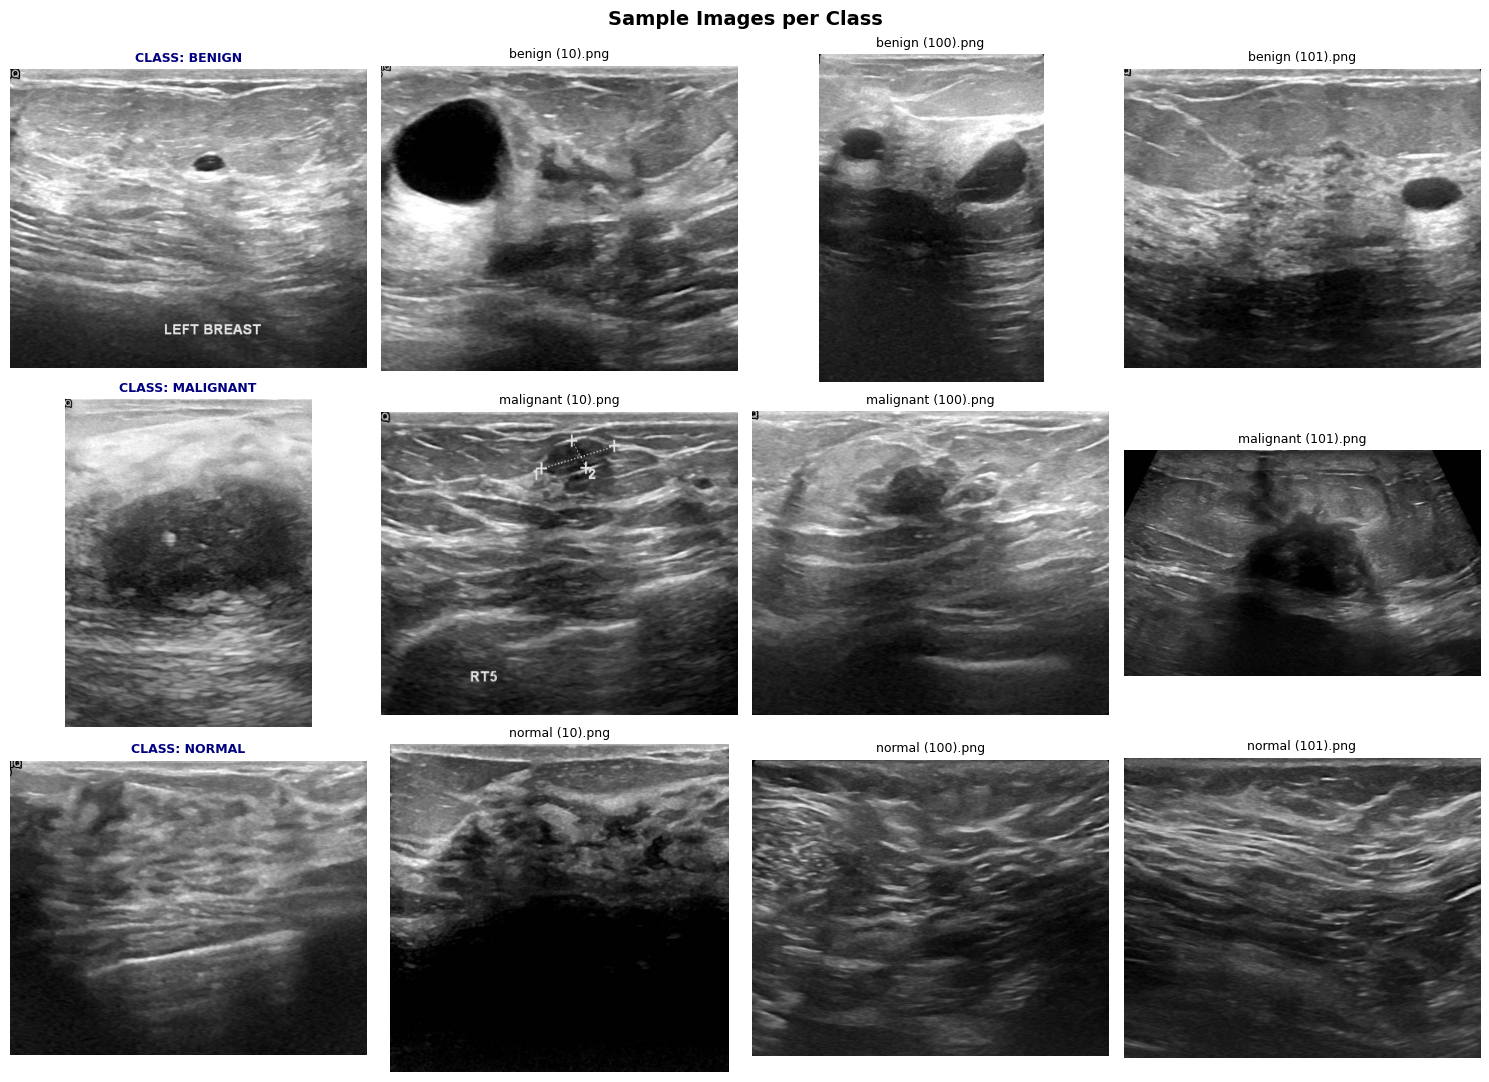

In [ ]:


fig, axes = plt.subplots(3, 4, figsize=(15, 11))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')

for row, class_name in enumerate(CONFIG['class_names']):
    samples = df[df['label_name'] == class_name]['filepath'].values[:4]
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        axes[row][col].set_title(
            f'CLASS: {class_name.upper()}' if col == 0 else os.path.basename(img_path),
            fontweight='bold' if col == 0 else 'normal',
            fontsize=9, color='navy' if col == 0 else 'black'
        )

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:


X = df['filepath'].values
y = df['label'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=SEED
)

print('Split summary:')
print(f'  Train : {len(X_train)} images')
print(f'  Val   : {len(X_val)} images')
print(f'  Test  : {len(X_test)} images')
print(f'\nTrain class counts: {Counter(y_train)}')
print(f'Val   class counts: {Counter(y_val)}')
print(f'Test  class counts: {Counter(y_test)}')

Split summary:
  Train : 546 images
  Val   : 78 images
  Test  : 156 images

Train class counts: Counter({np.int64(0): 306, np.int64(1): 147, np.int64(2): 93})
Val   class counts: Counter({np.int64(0): 44, np.int64(1): 21, np.int64(2): 13})
Test  class counts: Counter({np.int64(0): 87, np.int64(1): 42, np.int64(2): 27})


In [ ]:


print('Before oversampling:')
print(' ', {IDX_TO_CLASS[k]: v for k, v in Counter(y_train).items()})

X_train_2d             = X_train.reshape(-1, 1)
ros                    = RandomOverSampler(random_state=SEED)
X_train_res, y_train   = ros.fit_resample(X_train_2d, y_train)
X_train                = X_train_res.flatten()

print('After oversampling:')
print(' ', {IDX_TO_CLASS[k]: v for k, v in Counter(y_train).items()})
print(f'\nNew train size: {len(X_train)} images')
print('All classes now equal -> model sees each class equally often')

Before oversampling:
  {'benign': 306, 'normal': 93, 'malignant': 147}
After oversampling:
  {'benign': 306, 'normal': 306, 'malignant': 306}

New train size: 918 images
All classes now equal -> model sees each class equally often


In [ ]:


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights[1] = class_weights[1] * 1.3

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (higher = more penalty for mistakes):')
for i, w in enumerate(class_weights):
    bar = '#' * int(w * 10)
    note = ' <-- boosted 30%' if i == 1 else ''
    print(f'  {IDX_TO_CLASS[i]:12}: {w:.4f}  {bar}{note}')
print()
print('Malignant weight boosted because missing cancer = worst outcome')

Class weights (higher = more penalty for mistakes):
  benign      : 1.0000  ##########
  malignant   : 1.3000  ############# <-- boosted 30%
  normal      : 1.0000  ##########

Malignant weight boosted because missing cancer = worst outcome


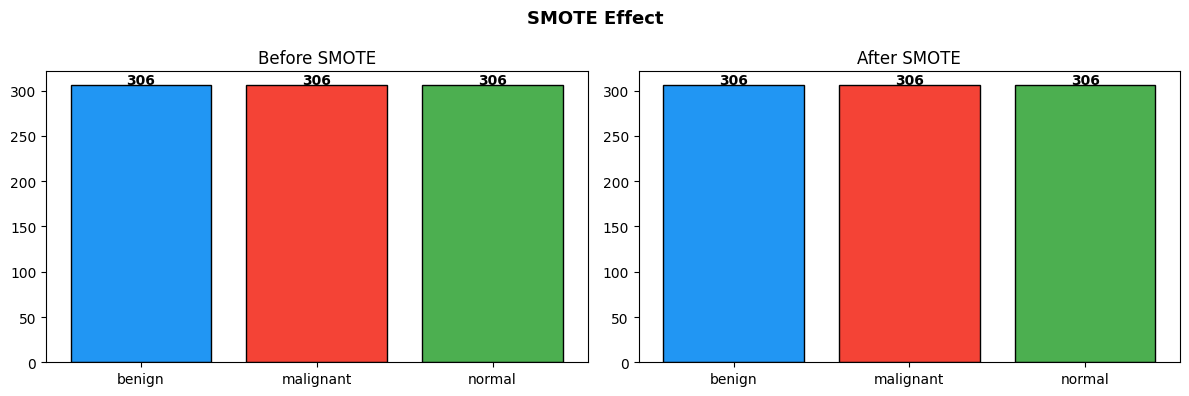

In [ ]:


dummy_X     = np.column_stack([np.arange(len(y_train)), y_train])
k_neighbors = min(5, min(Counter(y_train).values()) - 1)
smote       = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
_, y_smote  = smote.fit_resample(dummy_X, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SMOTE Effect', fontsize=13, fontweight='bold')

before     = Counter(y_train)
after      = Counter(y_smote)
cls_labels = [IDX_TO_CLASS[i] for i in sorted(before.keys())]
colors     = ['#2196F3', '#F44336', '#4CAF50']

axes[0].bar(cls_labels, [before[i] for i in sorted(before.keys())],
            color=colors, edgecolor='black')
axes[0].set_title('Before SMOTE')
for i, v in enumerate([before[j] for j in sorted(before.keys())]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].bar(cls_labels, [after[i] for i in sorted(after.keys())],
            color=colors, edgecolor='black')
axes[1].set_title('After SMOTE')
for i, v in enumerate([after[j] for j in sorted(after.keys())]):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_effect.png', dpi=120, bbox_inches='tight')
plt.show()

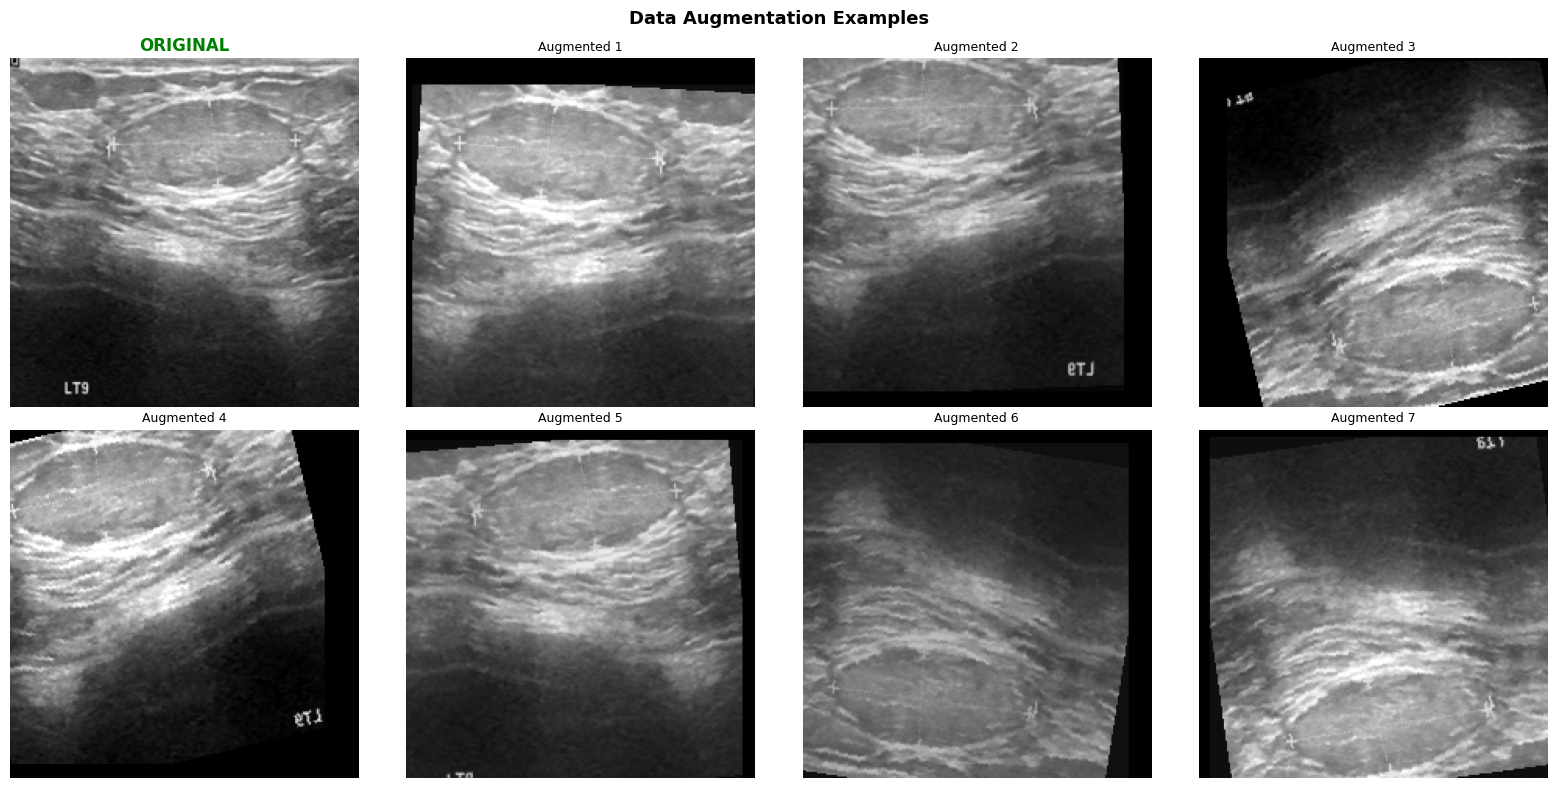

Augmentation creates variety -> better generalization


In [ ]:


IMG_SIZE = CONFIG['img_size']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


orig_img = Image.open(X_train[0]).convert('RGB')

def denorm(tensor):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip([0.485,0.456,0.406],[0.229,0.224,0.225])):
        t[c] = t[c] * s + m
    return t.clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
axes[0][0].imshow(orig_img.resize((IMG_SIZE, IMG_SIZE)))
axes[0][0].set_title('ORIGINAL', fontweight='bold', color='green')
axes[0][0].axis('off')
for i in range(1, 8):
    r, c = divmod(i, 4)
    axes[r][c].imshow(denorm(train_transforms(orig_img)))
    axes[r][c].set_title(f'Augmented {i}', fontsize=9)
    axes[r][c].axis('off')
plt.tight_layout()
plt.savefig('augmentation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Augmentation creates variety -> better generalization')

In [ ]:


class BUSIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None, use_roi=True):
        self.filepaths = filepaths
        self.labels    = labels
        self.transform = transform
        self.use_roi   = use_roi  

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        if self.use_roi:
            img = crop_with_mask(self.filepaths[idx])  # ROI crop
        else:
            img = Image.open(self.filepaths[idx]).convert('RGB')

        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


train_dataset = BUSIDataset(X_train, y_train, transform=train_transforms,    use_roi=True)
val_dataset   = BUSIDataset(X_val,   y_val,   transform=val_test_transforms, use_roi=True)
test_dataset  = BUSIDataset(X_test,  y_test,  transform=val_test_transforms, use_roi=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders ready (with ROI cropping):')
print(f'  Train : {len(train_loader)} batches ({len(train_dataset)} images)')
print(f'  Val   : {len(val_loader)} batches')
print(f'  Test  : {len(test_loader)} batches')
imgs, lbls = next(iter(train_loader))
print(f'\nBatch shape: {imgs.shape}')

DataLoaders ready (with ROI cropping):
  Train : 29 batches (918 images)
  Val   : 3 batches
  Test  : 5 batches

Batch shape: torch.Size([32, 3, 224, 224])


In [ ]:


class BUSIModel(nn.Module):
    def __init__(self, num_classes=3):
        super(BUSIModel, self).__init__()

        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        for param in self.backbone.parameters():
            param.requires_grad = False

        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        in_features = self.backbone.fc.in_features  # 2048
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


model     = BUSIModel(num_classes=CONFIG['num_classes']).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model: ResNet50 with custom head')
print(f'  Total parameters    : {total:,}')
print(f'  Trainable parameters: {trainable:,}')
print(f'  Frozen parameters   : {total-trainable:,}')
print()
print('Flow: Input(224x224) -> ResNet50 -> Linear(2048->256) -> ReLU -> Dropout -> Linear(256->3)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


Model: ResNet50 with custom head
  Total parameters    : 24,033,347
  Trainable parameters: 15,490,051
  Frozen parameters   : 8,543,296

Flow: Input(224x224) -> ResNet50 -> Linear(2048->256) -> ReLU -> Dropout -> Linear(256->3)


In [ ]:

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1         
)

# IMPROVEMENT: AdamW instead of Adam, adds weight decay
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['lr'],
    weight_decay=1e-4            #  L2 regularization
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience   = patience
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_f1):
        if self.best_score is None or val_f1 > self.best_score:
            self.best_score = val_f1
            self.counter    = 0
        else:
            self.counter += 1
            print(f'  Early stopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(patience=CONFIG['patience'])

print('Training setup:')
print(f'  Loss      : CrossEntropyLoss + class weights + label_smoothing=0.1')
print(f'  Optimizer : AdamW (lr={CONFIG["lr"]}, weight_decay=1e-4)')
print(f'  Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)')
print(f'  EarlyStop : patience={CONFIG["patience"]}')

Training setup:
  Loss      : CrossEntropyLoss + class weights + label_smoothing=0.1
  Optimizer : AdamW (lr=0.0001, weight_decay=1e-4)
  Scheduler : ReduceLROnPlateau (patience=3, factor=0.5)
  EarlyStop : patience=10


In [ ]:


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)


# --- Run Training ---
history = {'train_loss':[], 'val_loss':[], 'train_acc':[],
           'val_acc':[], 'train_f1':[], 'val_f1':[]}
best_val_f1    = 0.0
best_model_wts = None

print(f'Training for up to {CONFIG["num_epochs"]} epochs...')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Val F1":>7}')
print('-' * 65)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_wts, 'best_model.pth')
        marker = '  <-- best'

    print(f'{epoch:>5} | {train_loss:>10.4f} | {train_acc:>9.4f} | '
          f'{val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>7.4f}{marker}')

    early_stop(val_f1)
    if early_stop.stop:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest Val F1: {best_val_f1:.4f}')

Training for up to 50 epochs...
Epoch | Train Loss | Train Acc | Val Loss | Val Acc |  Val F1
-----------------------------------------------------------------
    1 |     0.9306 |    0.6253 |   0.8354 |  0.7179 |  0.7125  <-- best
    2 |     0.5917 |    0.8529 |   0.6069 |  0.9103 |  0.9117  <-- best
    3 |     0.4922 |    0.8954 |   0.5607 |  0.8718 |  0.8678
  Early stopping: 1/10
    4 |     0.4601 |    0.9107 |   0.4717 |  0.8974 |  0.8989
  Early stopping: 2/10
    5 |     0.4536 |    0.9118 |   0.4958 |  0.8974 |  0.9005
  Early stopping: 3/10
    6 |     0.4392 |    0.9205 |   0.5936 |  0.8718 |  0.8652
  Early stopping: 4/10
    7 |     0.4311 |    0.9336 |   0.4418 |  0.9359 |  0.9374  <-- best
    8 |     0.4148 |    0.9401 |   0.4681 |  0.9231 |  0.9225
  Early stopping: 1/10
    9 |     0.4163 |    0.9357 |   0.4860 |  0.9103 |  0.9083
  Early stopping: 2/10
   10 |     0.4002 |    0.9423 |   0.4802 |  0.9231 |  0.9239
  Early stopping: 3/10
   11 |     0.3786 |    0.966

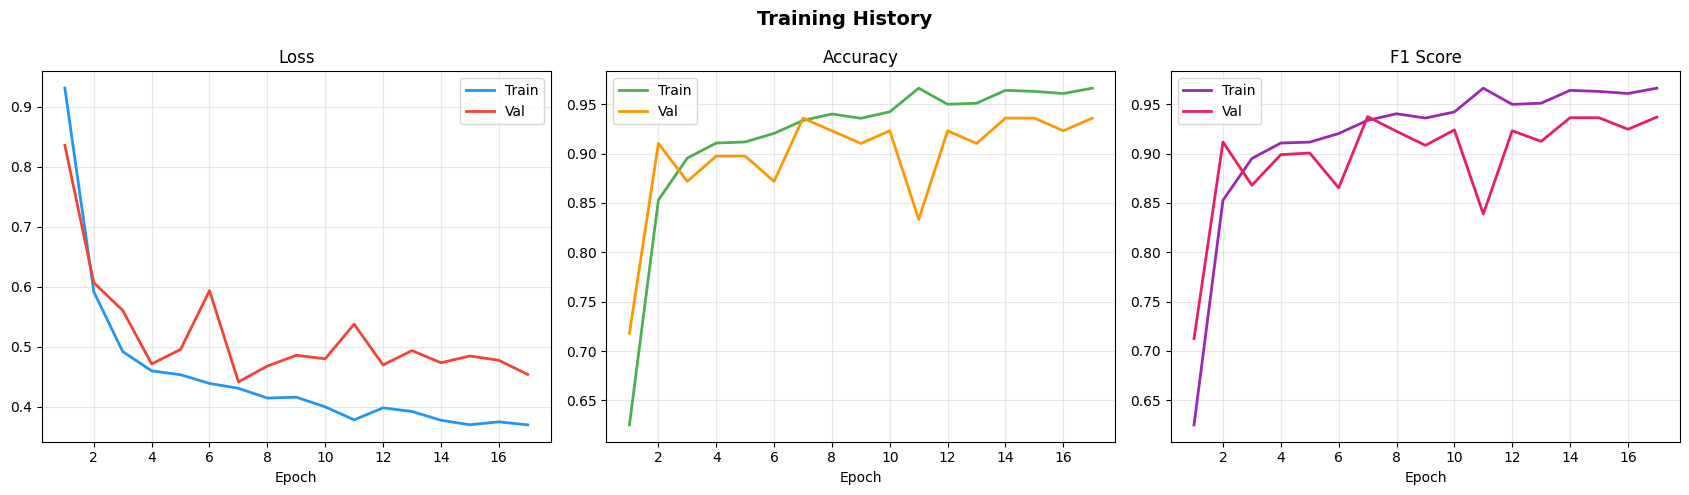

If train and val curves are close -> good generalization
If train goes up but val drops -> overfitting


In [ ]:


epochs_done = range(1, len(history['train_loss']) + 1)
fig, axes   = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(epochs_done, history['train_loss'], label='Train', color='#2196F3', linewidth=2)
axes[0].plot(epochs_done, history['val_loss'],   label='Val',   color='#F44336', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_done, history['train_acc'], label='Train', color='#4CAF50', linewidth=2)
axes[1].plot(epochs_done, history['val_acc'],   label='Val',   color='#FF9800', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_done, history['train_f1'], label='Train', color='#9C27B0', linewidth=2)
axes[2].plot(epochs_done, history['val_f1'],   label='Val',   color='#E91E63', linewidth=2)
axes[2].set_title('F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('If train and val curves are close -> good generalization')
print('If train goes up but val drops -> overfitting')

In [ ]:


model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE,
                                  weights_only=True))
print('Best model loaded.')

test_loss, test_acc, test_f1, y_pred, y_true, y_probs = evaluate(
    model, test_loader, criterion
)

print(f'\nTest Results:')
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'  F1 Score : {test_f1:.4f}')
print()

print('Sample Predictions:')
print(f'  {"True":15} {"Predicted":15} {"Correct?":10}')
print('  ' + '-' * 42)
for i in range(min(10, len(y_true))):
    true  = IDX_TO_CLASS[y_true[i]]
    pred  = IDX_TO_CLASS[y_pred[i]]
    check = 'YES' if y_true[i] == y_pred[i] else 'NO'
    print(f'  {true:15} {pred:15} {check:10}')

print()
print('Classification Report:')
print(classification_report(y_true, y_pred,
                             target_names=CONFIG['class_names'], digits=3))

Best model loaded.

Test Results:
  Loss     : 0.6139
  Accuracy : 0.8462 (84.6%)
  F1 Score : 0.8469

Sample Predictions:
  True            Predicted       Correct?  
  ------------------------------------------
  normal          normal          YES       
  benign          benign          YES       
  benign          malignant       NO        
  benign          benign          YES       
  malignant       malignant       YES       
  normal          normal          YES       
  benign          benign          YES       
  benign          benign          YES       
  benign          benign          YES       
  malignant       malignant       YES       

Classification Report:
              precision    recall  f1-score   support

      benign      0.920     0.793     0.852        87
   malignant      0.720     0.857     0.783        42
      normal      0.871     1.000     0.931        27

    accuracy                          0.846       156
   macro avg      0.837     0.883     0.8

In [ ]:


y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
colors_roc = ['#2196F3', '#F44336', '#4CAF50']

acc        = accuracy_score(y_true, y_pred)
bal_acc    = balanced_accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average='macro',    zero_division=0)
prec_wt    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_macro  = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
rec_wt     = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
f1_macro   = f1_score(y_true, y_pred,        average='macro',    zero_division=0)
f1_wt      = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
f1_per_cls = f1_score(y_true, y_pred,        average=None,       zero_division=0)
kappa      = cohen_kappa_score(y_true, y_pred)
mcc        = matthews_corrcoef(y_true, y_pred)
ll         = log_loss(y_true, y_probs)

try:
    roc_auc = roc_auc_score(y_true_bin, y_probs, average='macro', multi_class='ovr')
except:
    roc_auc = float('nan')

ap_per_cls = [average_precision_score(y_true_bin[:,i], y_probs[:,i]) for i in range(3)]
ap_macro   = np.mean(ap_per_cls)

cm = confusion_matrix(y_true, y_pred)
sensitivity, specificity = [], []
for i in range(3):
    tp = cm[i,i]; fn = cm[i,:].sum()-tp
    fp = cm[:,i].sum()-tp; tn = cm.sum()-tp-fn-fp
    sensitivity.append(tp/(tp+fn) if (tp+fn)>0 else 0)
    specificity.append(tn/(tn+fp) if (tn+fp)>0 else 0)

priors      = np.bincount(y_true) / len(y_true)
null_ll     = -np.mean(np.log(priors[y_true] + 1e-15))
mcfadden_r2 = 1 - (ll / null_ll)

print('=' * 60)
print('COMPLETE METRICS - TEST SET')
print('=' * 60)
print(f'  Accuracy                : {acc:.4f}')
print(f'  Balanced Accuracy       : {bal_acc:.4f}')
print(f'  Precision (macro)       : {prec_macro:.4f}')
print(f'  Precision (weighted)    : {prec_wt:.4f}')
print(f'  Recall (macro)          : {rec_macro:.4f}')
print(f'  Recall (weighted)       : {rec_wt:.4f}')
print(f'  F1 Score (macro)        : {f1_macro:.4f}')
print(f'  F1 Score (weighted)     : {f1_wt:.4f}')
print(f'  ROC-AUC (macro OvR)     : {roc_auc:.4f}')
print(f'  Avg Precision (macro)   : {ap_macro:.4f}')
print(f'  Cohen Kappa             : {kappa:.4f}')
print(f'  Matthews CC (MCC)       : {mcc:.4f}')
print(f'  Log Loss                : {ll:.4f}')
print(f'  McFadden R2 (pseudo R2) : {mcfadden_r2:.4f}')
print()
print(f'  {"Class":12} {"F1":>6} {"Sensitivity":>12} {"Specificity":>12}')
print('  ' + '-'*44)
for i, cls in enumerate(CONFIG['class_names']):
    print(f'  {cls:12} {f1_per_cls[i]:>6.4f} {sensitivity[i]:>12.4f} {specificity[i]:>12.4f}')
print('=' * 60)

COMPLETE METRICS - TEST SET
  Accuracy                : 0.8462
  Balanced Accuracy       : 0.8834
  Precision (macro)       : 0.8370
  Precision (weighted)    : 0.8577
  Recall (macro)          : 0.8834
  Recall (weighted)       : 0.8462
  F1 Score (macro)        : 0.8552
  F1 Score (weighted)     : 0.8469
  ROC-AUC (macro OvR)     : 0.9520
  Avg Precision (macro)   : 0.9217
  Cohen Kappa             : 0.7483
  Matthews CC (MCC)       : 0.7544
  Log Loss                : 0.4496
  McFadden R2 (pseudo R2) : 0.5424

  Class            F1  Sensitivity  Specificity
  --------------------------------------------
  benign       0.8519       0.7931       0.9130
  malignant    0.7826       0.8571       0.8772
  normal       0.9310       1.0000       0.9690


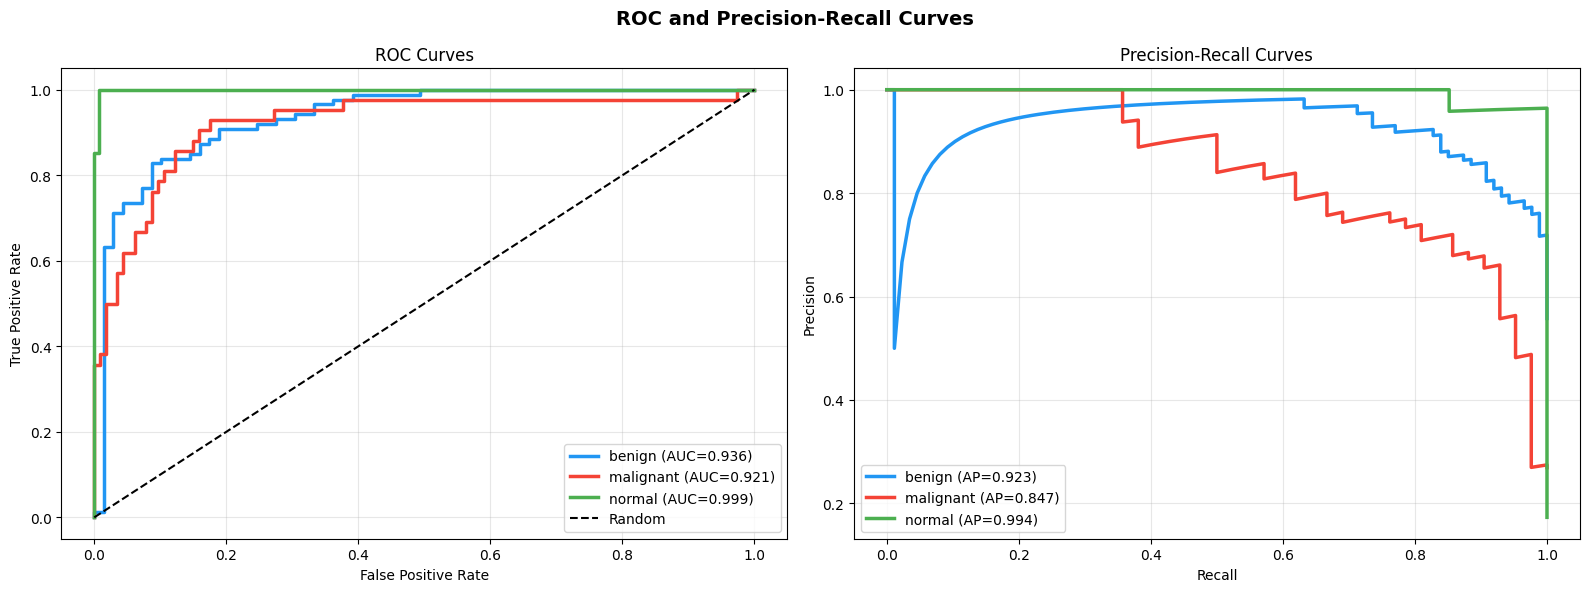

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')

for i, (cls, color) in enumerate(zip(CONFIG['class_names'], colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_probs[:,i])
    auc_val     = roc_auc_score(y_true_bin[:,i], y_probs[:,i])
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{cls} (AUC={auc_val:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, (cls, color) in enumerate(zip(CONFIG['class_names'], colors_roc)):
    p, r, _ = precision_recall_curve(y_true_bin[:,i], y_probs[:,i])
    ap      = average_precision_score(y_true_bin[:,i], y_probs[:,i])
    axes[1].plot(r, p, color=color, linewidth=2.5,
                 label=f'{cls} (AP={ap:.3f})')

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()